# Deep learning applied to gravitational lensing

## Import parameters

In [1]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

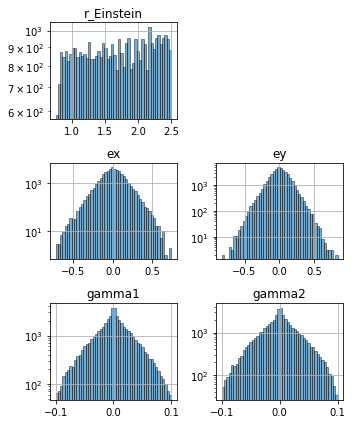

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(5, 6))
axes = axes.flatten()   
columns = ["r_Einstein", "ex", "ey", "gamma1", "gamma2"]
poss = [0,2,3,4,5]

for i, col in enumerate(columns):
    axes[poss[i]].hist(df[col], bins=50, alpha=0.6, log=True, edgecolor='black',linewidth=0.7)
    axes[poss[i]].set_title(col)
    axes[poss[i]].grid(True)

# axes[-2].axis("off")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/dataset_small.png", dpi=300, bbox_inches="tight")
plt.show()

## Images

In [6]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [10]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [11]:
import os
os.chdir("/home/mbatt")

In [12]:
df.sort_values(by = 'ex')

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,y_source,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2
16358,18730,1343,1,-0.041391,-0.039017,0.399109,1.573623,1.887927,3.970881,0.473372,...,-0.093959,-5.0,0.013947,0.678887,-0.725185,-0.004099,0.399109,1.110223e-16,0.002949,0.013632
20953,24302,4951,2,0.040127,0.008518,0.393891,1.657895,1.682797,3.706175,0.399806,...,0.009992,-2.0,0.024792,2.697300,-0.720307,-0.126761,0.393891,1.110223e-16,0.015631,-0.019243
27034,31667,1227,3,0.026842,-0.002480,0.373727,1.736918,1.446709,1.427032,0.473372,...,0.934996,-5.0,0.017419,1.542365,-0.713608,-0.246219,0.373727,2.220446e-16,-0.017391,0.000990
28780,33793,168,0,0.017049,0.034703,0.427293,1.616291,1.383334,4.704266,0.523713,...,-1.098067,-5.0,0.009919,2.341264,-0.688359,-0.062807,0.427293,5.551115e-17,-0.000296,-0.009915
39067,46264,1083,1,0.018042,-0.038491,0.417895,1.468720,0.990948,0.827810,0.360723,...,-0.526676,-3.0,0.030738,2.919065,-0.688063,0.142454,0.417895,-5.551115e-17,0.027743,-0.013233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42006,49886,1264,0,-0.002956,-0.016899,0.449628,0.098636,0.830712,4.781267,0.526391,...,0.140640,-4.0,0.019835,3.140057,0.650793,0.130075,0.449628,5.551115e-17,0.019835,-0.000061
39628,46951,1673,0,0.017491,-0.023225,0.456277,3.110450,0.916647,1.213749,0.620928,...,-0.127576,-4.0,0.062262,2.568732,0.654100,-0.040793,0.456277,1.110223e-16,0.025676,-0.056722
36472,43169,1161,1,0.027839,0.035458,0.445025,0.058208,1.082698,1.555112,0.637841,...,-0.224418,-3.0,0.004240,1.976507,0.664852,0.077751,0.445025,1.110223e-16,-0.002919,-0.003075
25685,30058,1668,2,-0.096321,-0.007982,0.356948,0.162278,1.478722,1.495840,0.473372,...,-0.246260,-3.0,0.036784,1.169982,0.733567,0.246811,0.356948,-1.110223e-16,-0.025585,0.026429


In [19]:
image_index = 10841

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_7/lens_12138_source_6945_r_1.fits


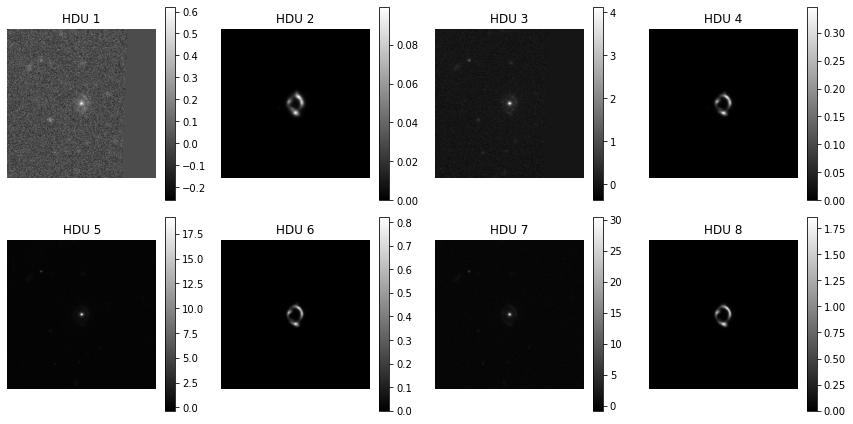

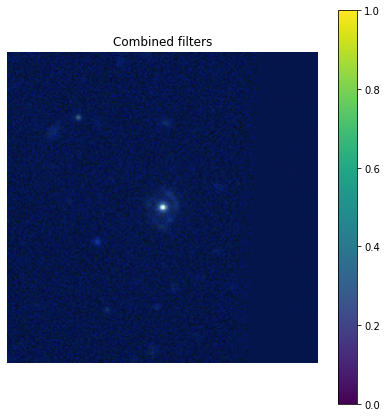

In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [21]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 4 
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [22]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [23]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location):
#     if ima_file.split('/')[1] + '.pt' not in LL:
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul), 2)]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12138_source_6945_r_1.fits.pt


/tmp/ipykernel_31304/4083360855.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


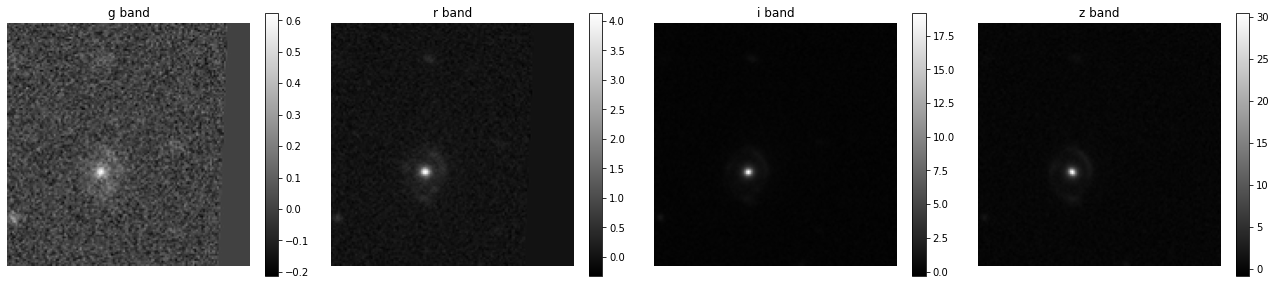

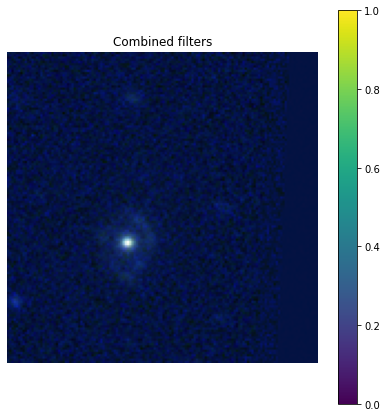

In [29]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# SIMPLE CNN

In [25]:
df_sample

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,1.110223e-16,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [26]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [33]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']

dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [34]:
dff = dff.sample(frac=1, random_state=42)

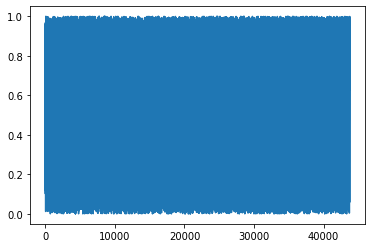

In [35]:
plt.plot(dff.r_Einstein.values)
plt.show()

## Load data

In [36]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [37]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

n = len(full_dataset)

test_size = int(0.2 * n)
remaining_size = n - test_size

generator = torch.Generator().manual_seed(42)

remaining_dataset, test_dataset = random_split(
    full_dataset,
    [remaining_size, test_size],
    generator=generator)

train_size = int(0.6 * n)
val_size = remaining_size - train_size

train_dataset, val_dataset = random_split(
    remaining_dataset,
    [train_size, val_size])

In [38]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=3)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=3)

## Import Models

In [39]:
from deep_learning_models import ResNetHoliSmokes
from deep_learning_models import ResNetMini

In [40]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [41]:
import torch
from torchviz import make_dot

# model = ResNetMini()   
model = ResNetHoliSmokes()
x = torch.randn(1, 4, 140, 140) 

y = model(x)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("resnetmini", directory=".", cleanup=True)  # creates resnetmini.png in current folder

'resnetmini.png'

In [42]:
from IPython.display import Image

# Image("resnetmini.png")


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# weights = torch.tensor([0.3, 0.3, 0.3, 0.05, 0.05], device=device)
weights = torch.tensor([1, 1, 1, 1, 1], device=device)

In [44]:
import torch.nn.functional as F

def weighted_mse(pred, target, weights):
    loss = F.mse_loss(pred, target, reduction='none')
    loss = loss * weights
    return loss.mean()                                 


In [45]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

patience = 10
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

model = ResNetHoliSmokes().to(device)


criterion = nn.MSELoss(reduction = "none")
# optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None

for epoch in range(60):

    # ---- TRAIN ----
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad() # It resets gradients to zero so they don’t accumulate from previous batches.
        outputs = model(xb)
        loss = weighted_mse(outputs, yb, weights)
        loss.backward() # computes gradients
        optimizer.step() # applies them to the model

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = weighted_mse(outputs, yb, weights)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))
    
    scheduler.step()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()  
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
    
        # ---- EARLY STOPPING ----
    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch 1: train=0.0172, val=0.0217
Epoch 2: train=0.0129, val=0.0917
Epoch 3: train=0.0114, val=0.0409
Epoch 4: train=0.0104, val=0.0331
Epoch 5: train=0.0097, val=0.0097
Epoch 6: train=0.0093, val=0.1348
Epoch 7: train=0.0089, val=0.0262
Epoch 8: train=0.0085, val=0.3865
Epoch 9: train=0.0082, val=0.0376
Epoch 10: train=0.0078, val=0.3721
Epoch 11: train=0.0065, val=0.8305
Epoch 12: train=0.0062, val=0.2126
Epoch 13: train=0.0060, val=0.2043
Epoch 14: train=0.0058, val=0.2059
Epoch 15: train=0.0056, val=0.1355
Early stopping triggered at epoch 15


In [34]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [35]:
torch.save({
    "model": best_weights,
    "optimizer": optimizer.state_dict(),
    "epoch": epoch,
    "train_losses": train_losses,
    "val_losses": val_losses
}, "resnet_sqrt_25.pth")

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetHoliSmokes().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
checkpoint = torch.load("model_nn.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


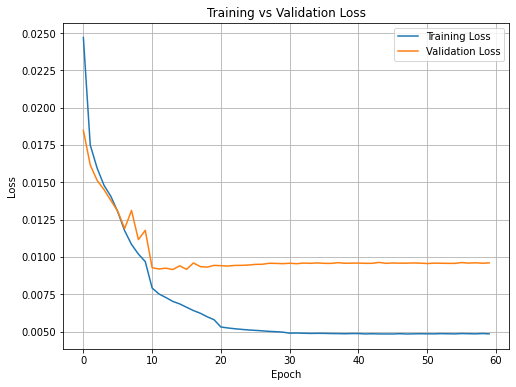

In [47]:
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_arcsinh6_loss.png", dpi=300)
plt.show()


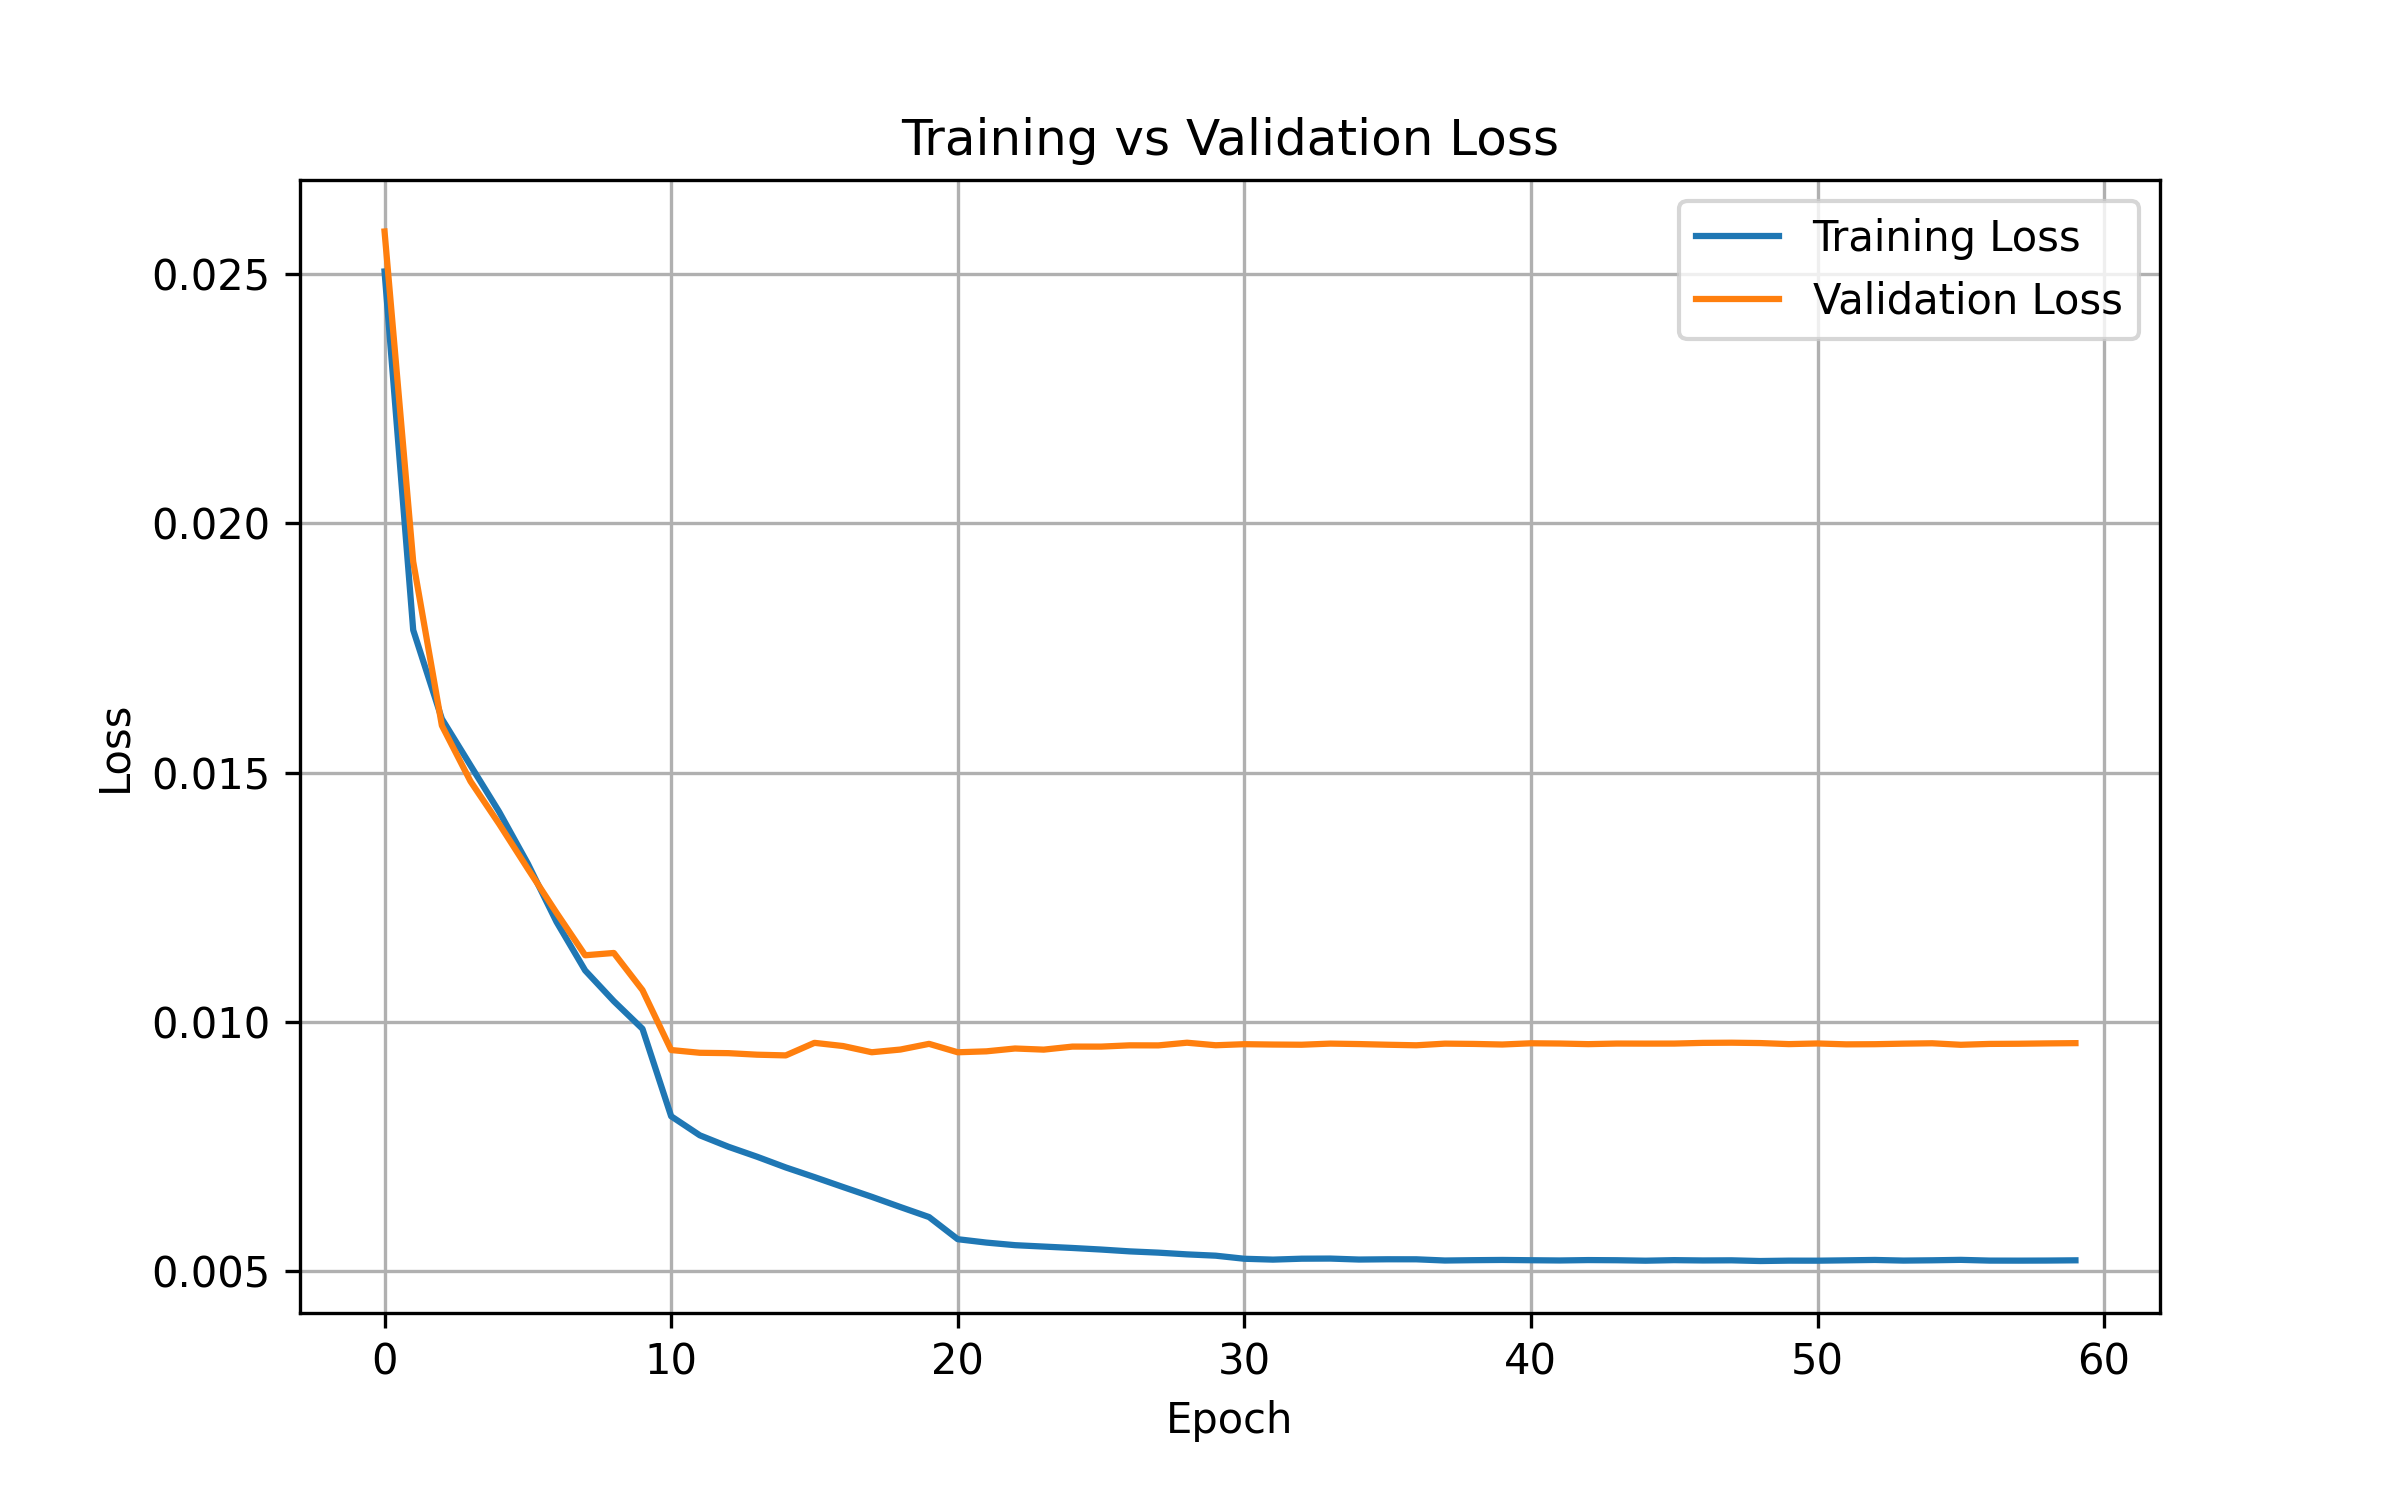

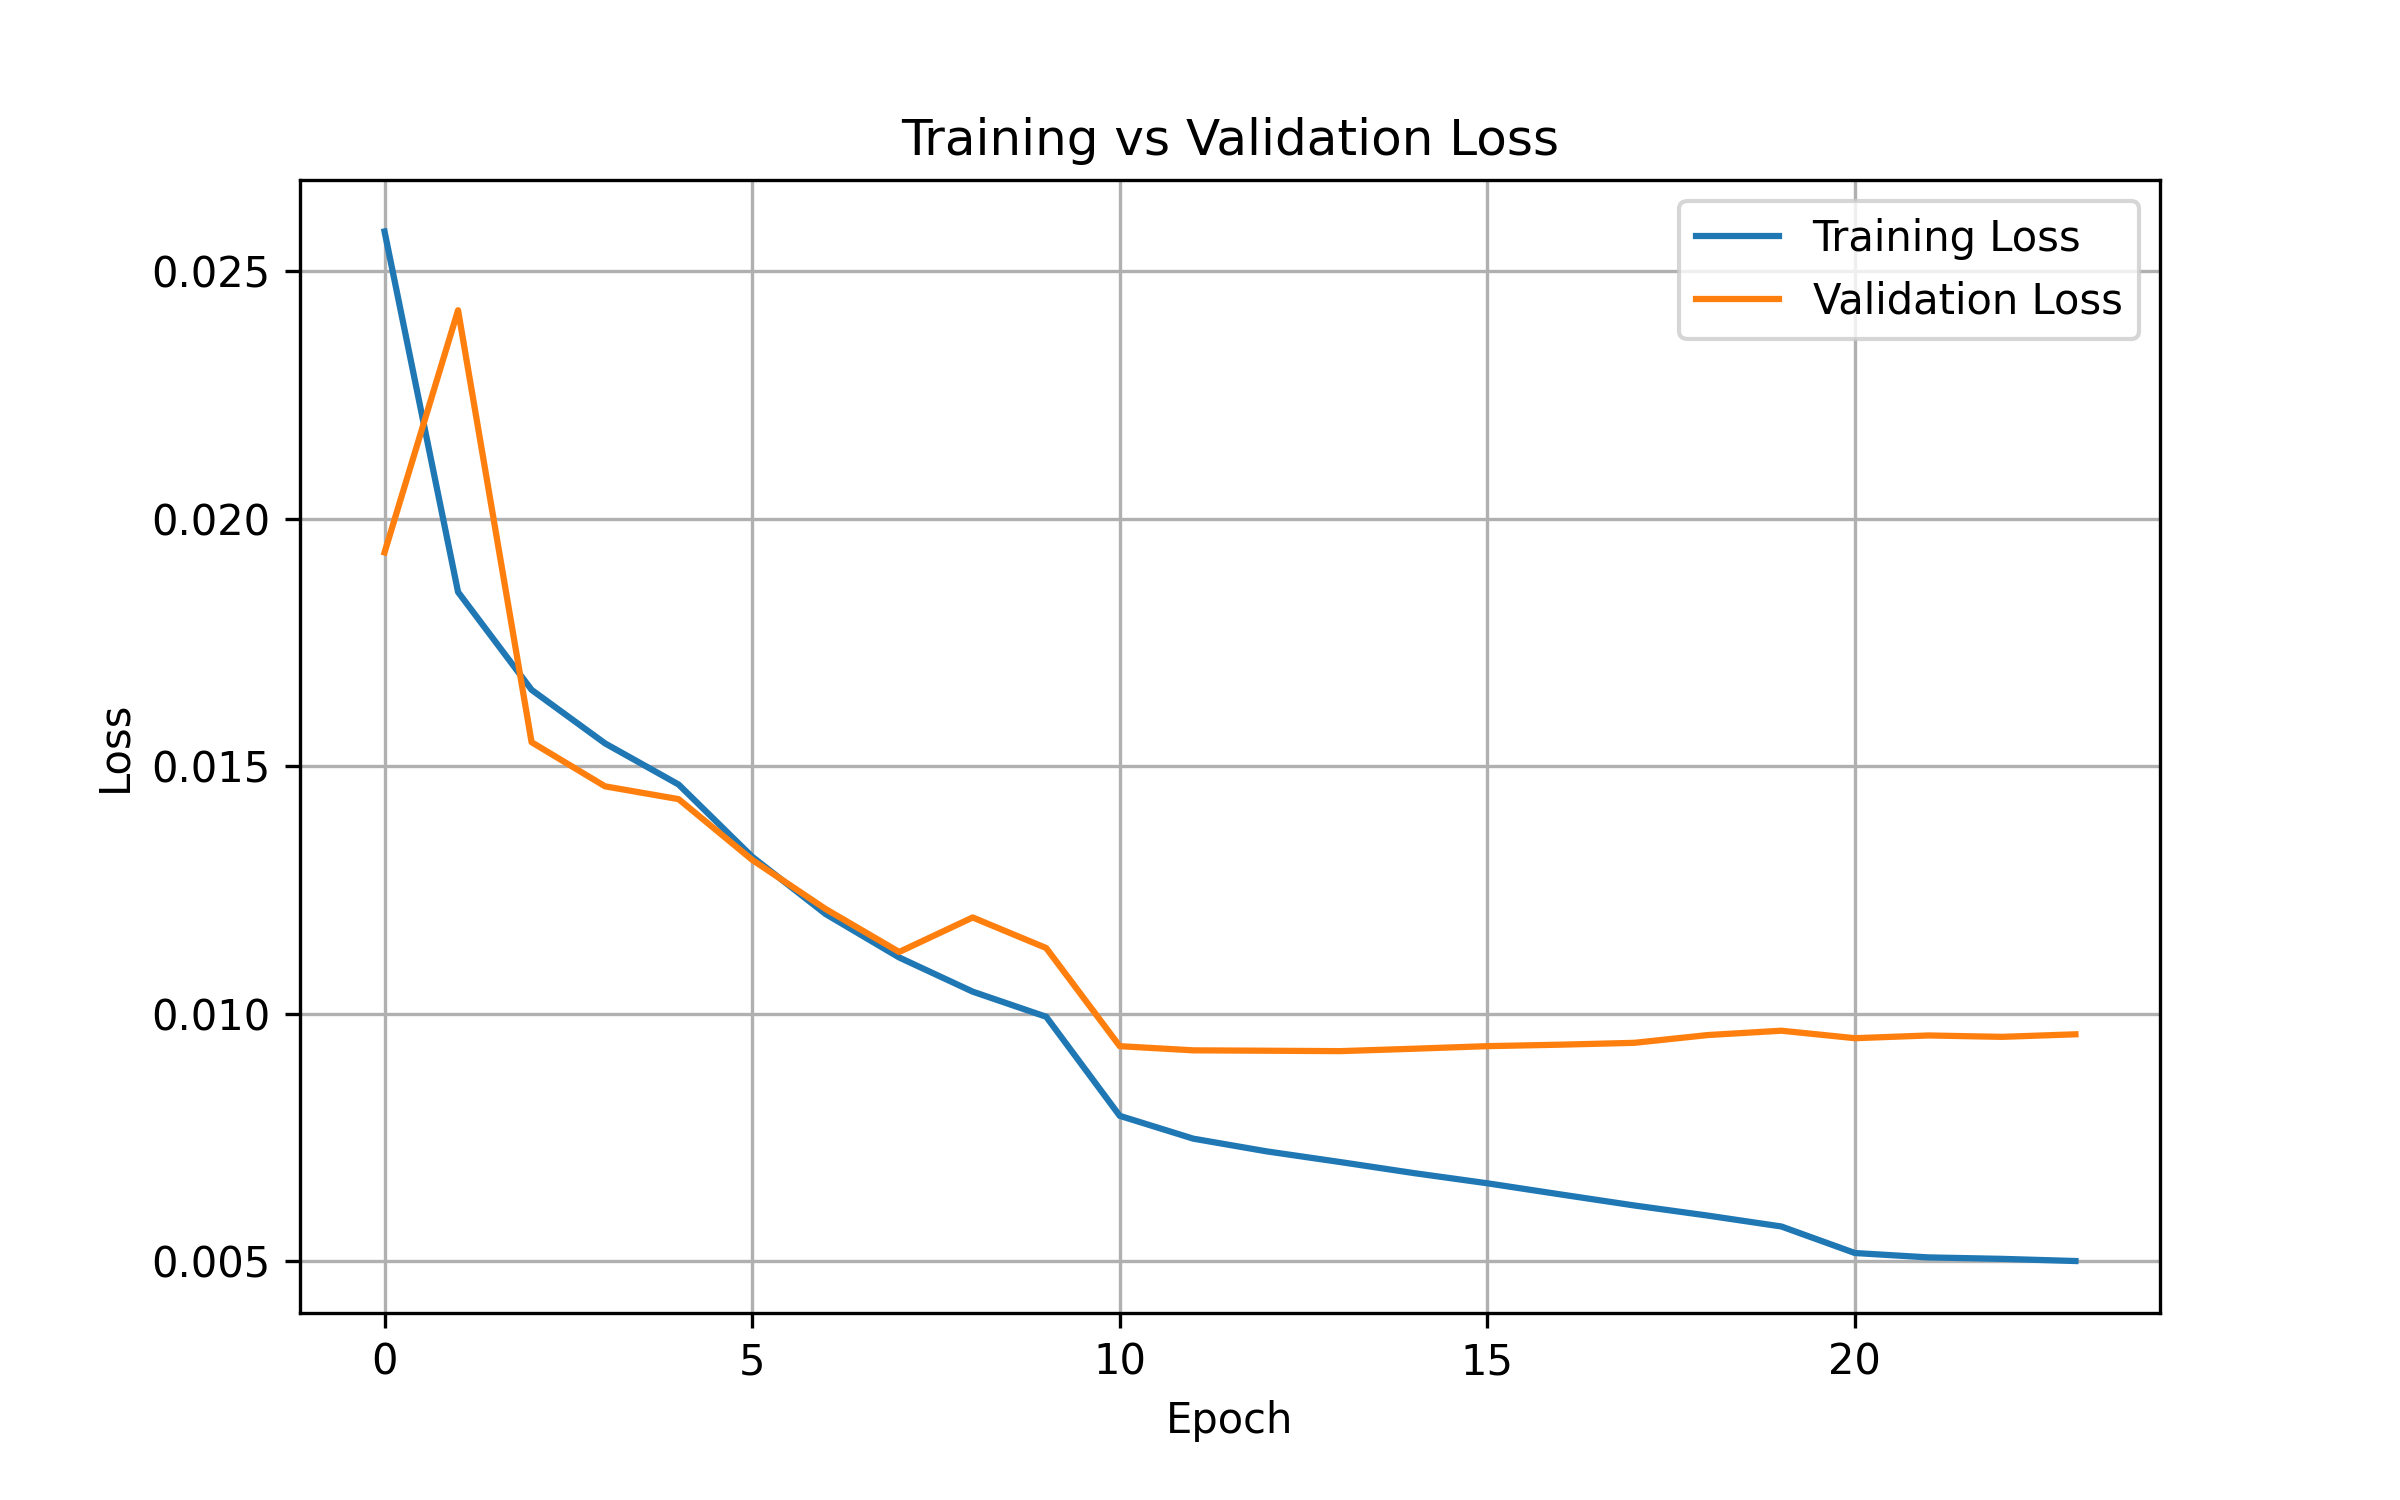

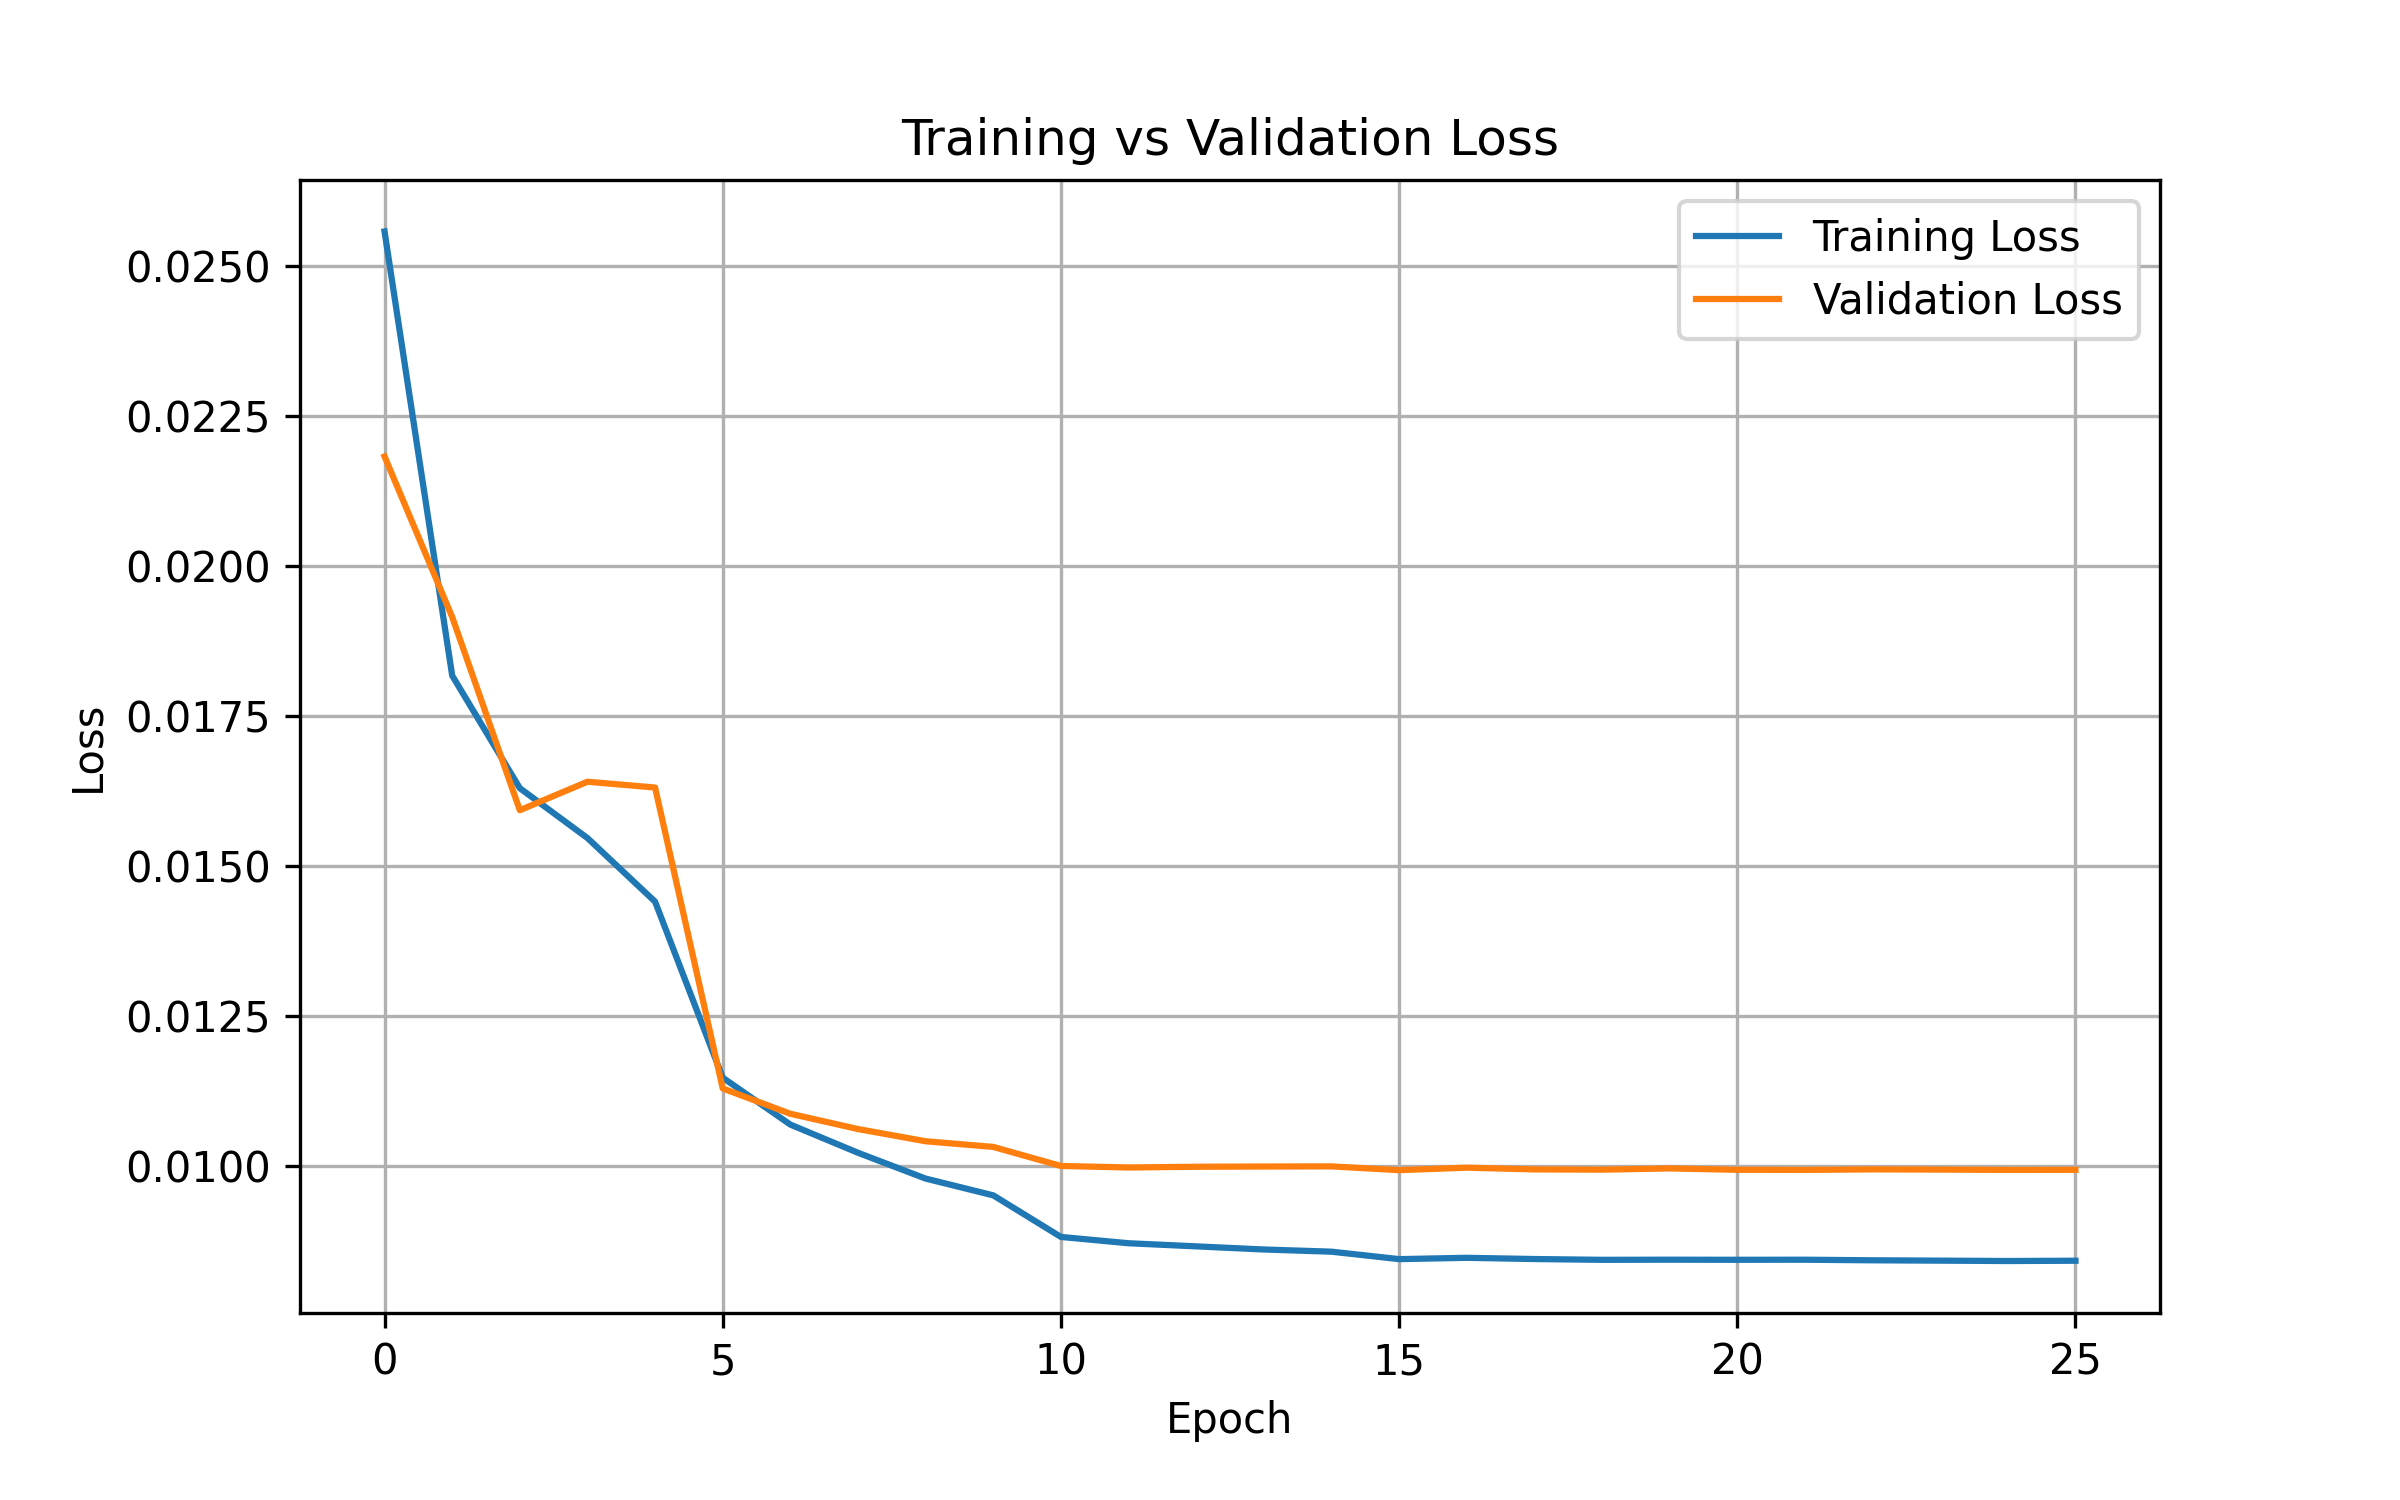

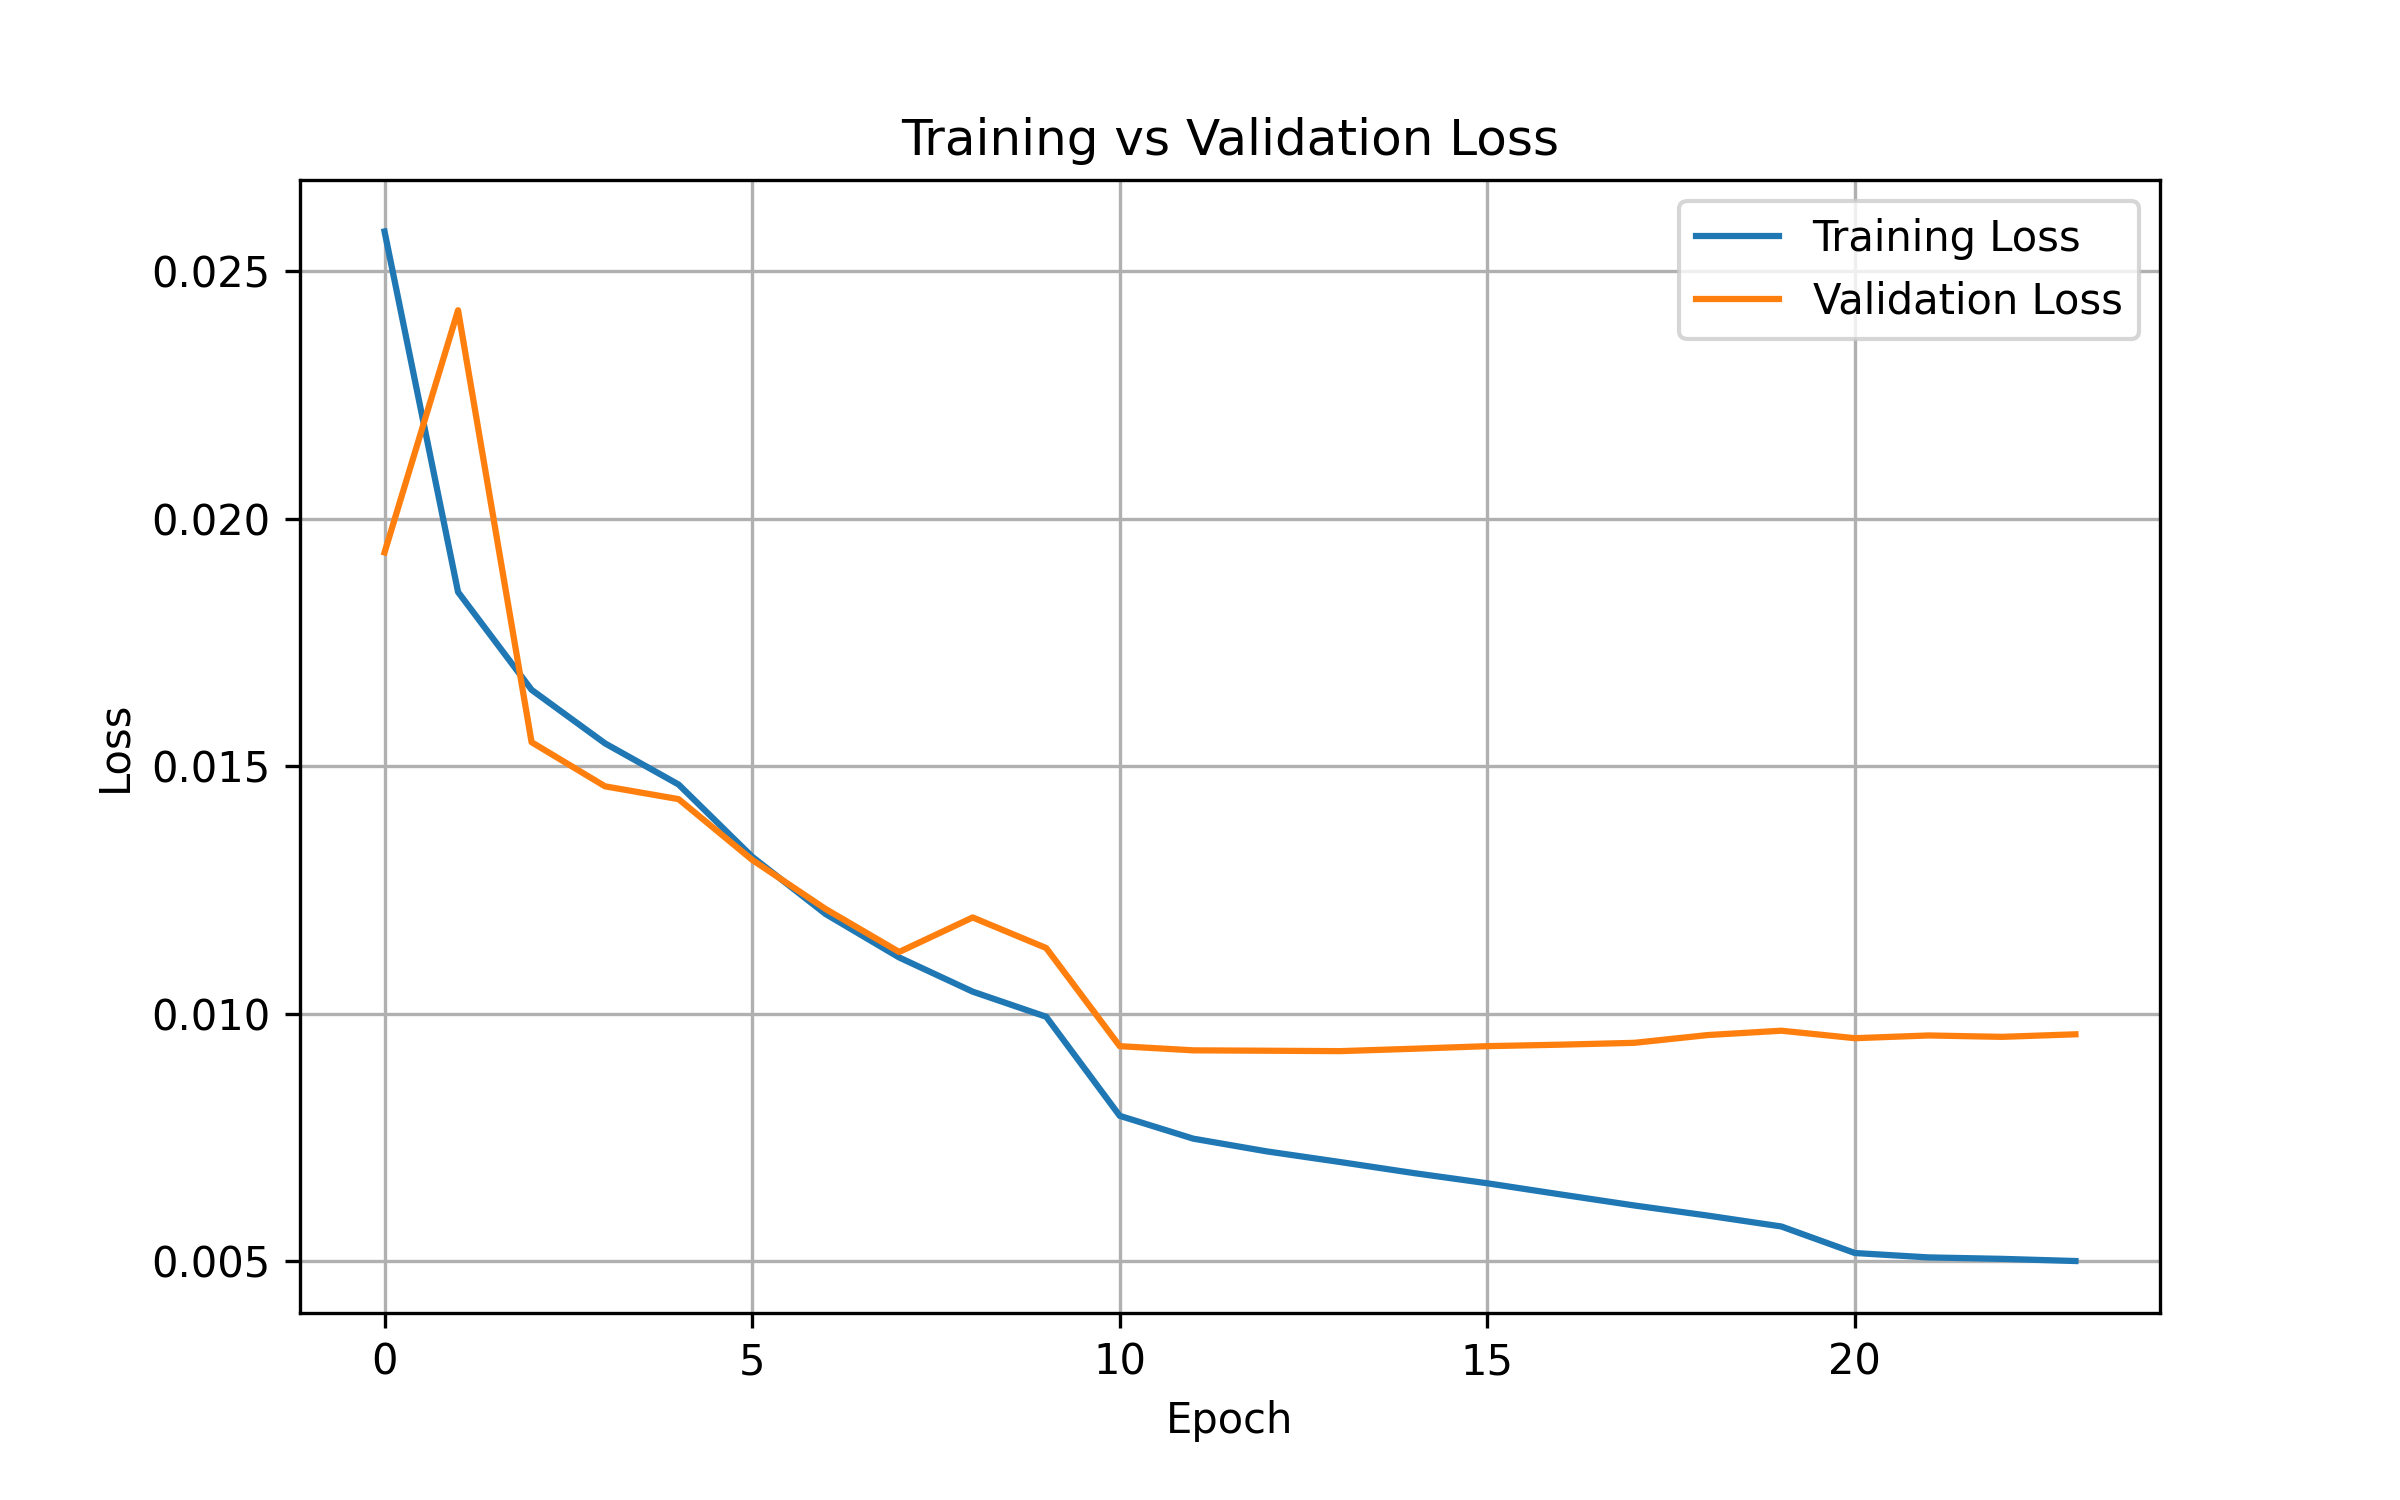

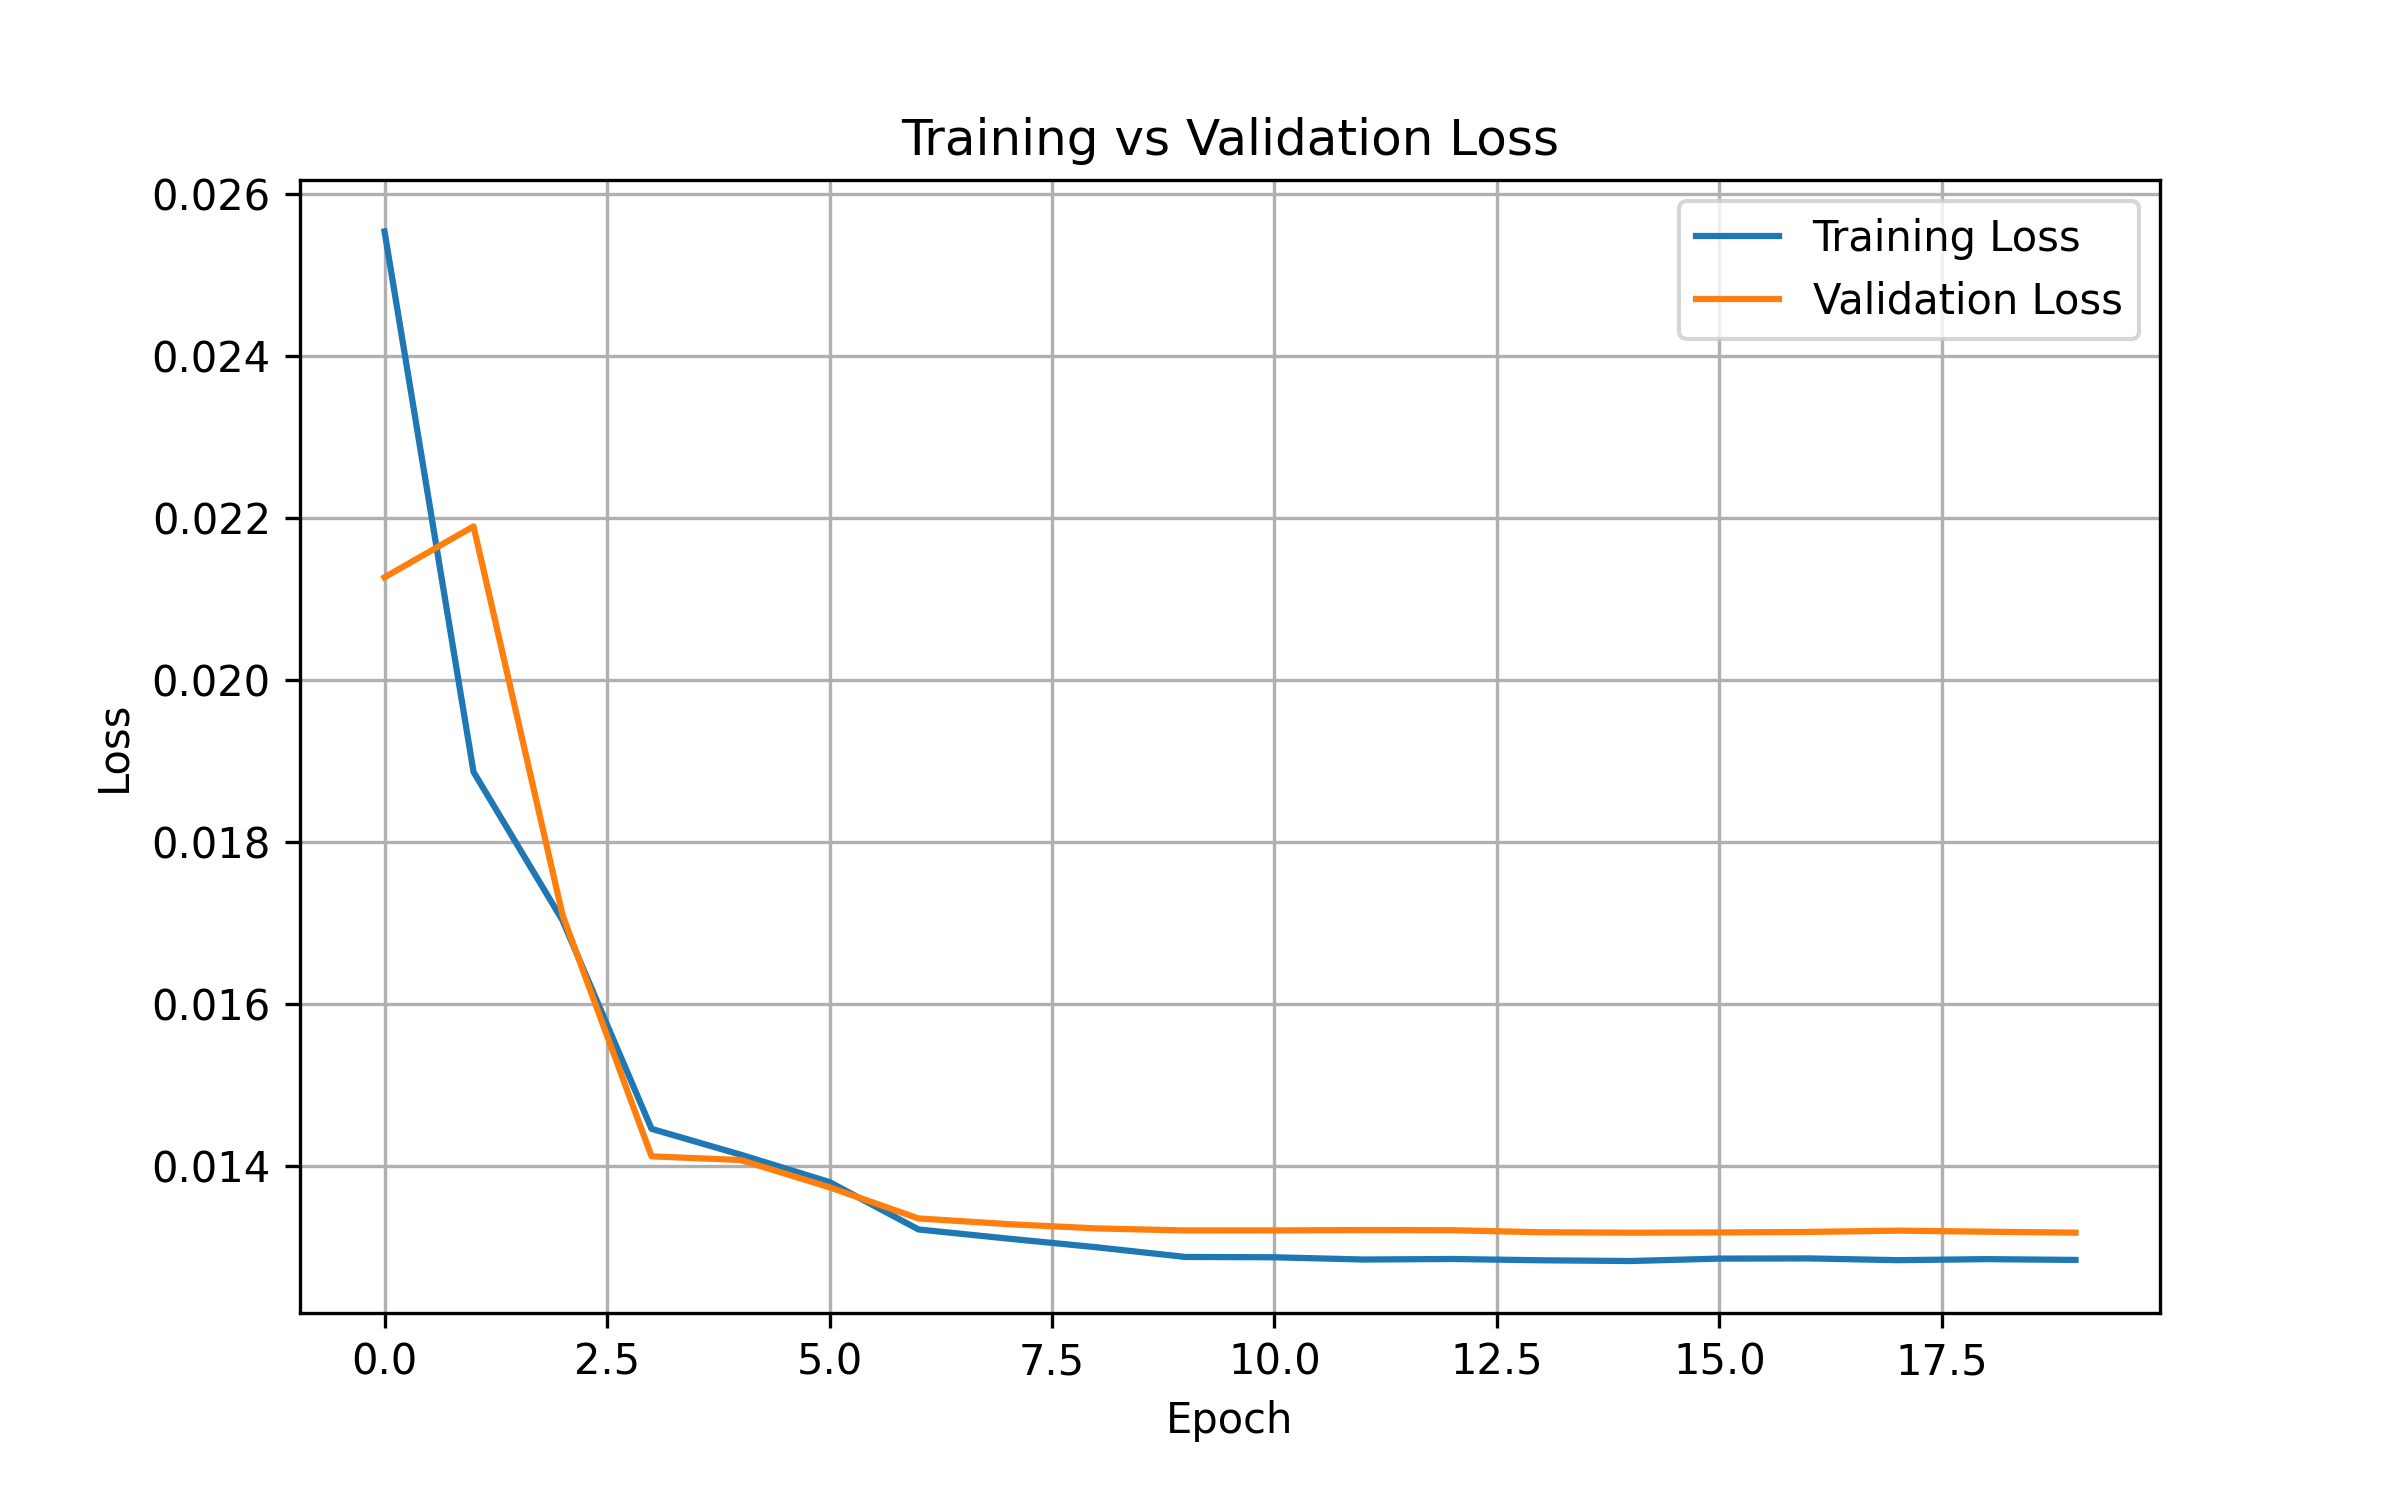

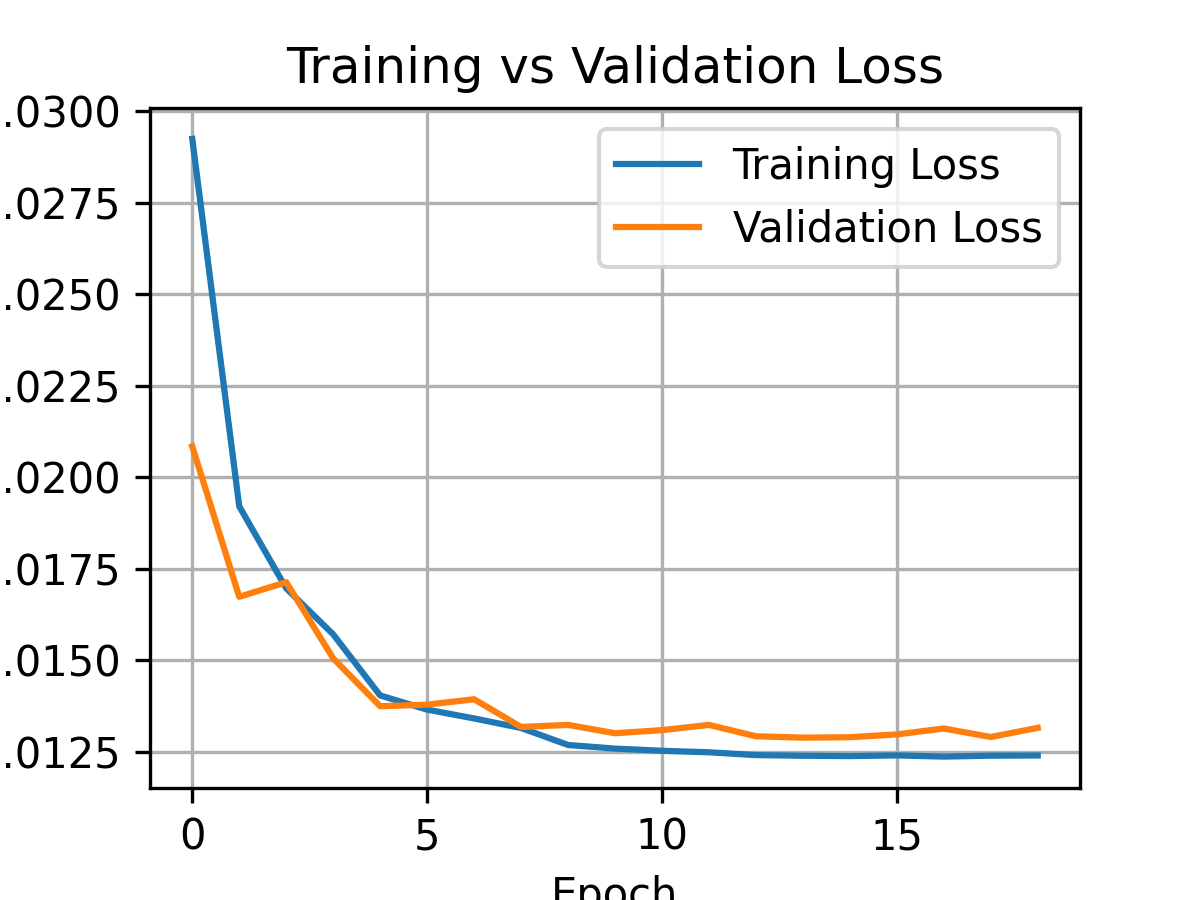

In [38]:
from IPython.display import Image, display
path = "/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/"
display(Image(path + "resnet_arcsinh_loss.png"))
display(Image(path + "resnet_arcsinh2_loss.png"))
display(Image(path + "resnet_arcsinh3_loss.png"))
display(Image(path + "resnet_arcsinh4_loss.png"))
display(Image(path + "resnet_arcsinh5_loss.png"))
display(Image(path + "resnet_arcsinh6_loss.png"))

In [48]:
model.eval()
preds = []
targets = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(xb)

        preds.append(out.cpu())
        targets.append(yb.cpu())


# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0058, 0.0187, 0.0180, 0.0027, 0.0021])
Per-parameter R2: [0.9301829636096954, 0.28689855337142944, 0.30742037296295166, 0.7273764312267303, 0.7357121109962463]


In [49]:
targets.shape

torch.Size([8746, 5])

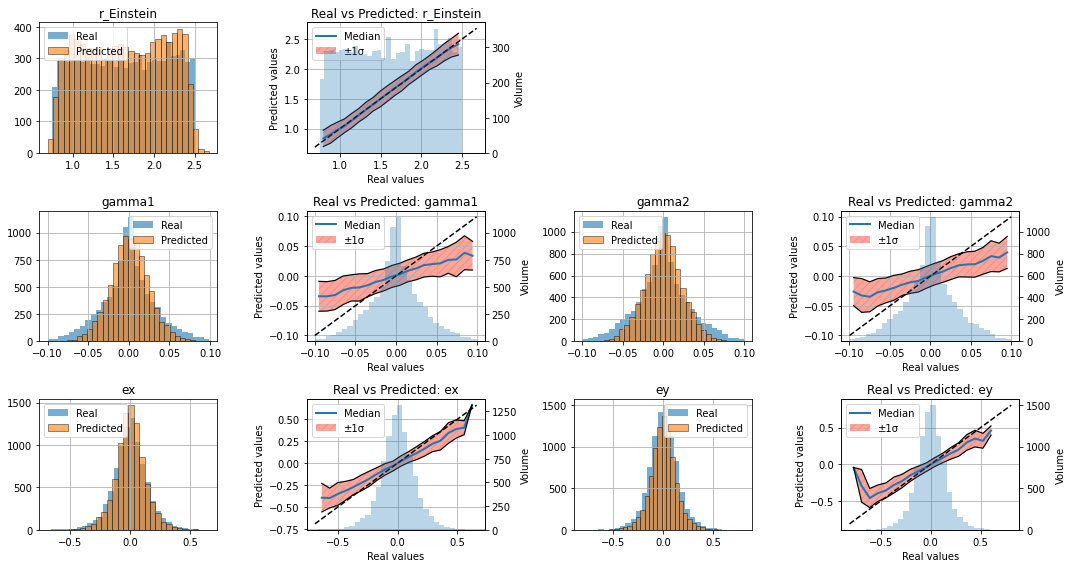

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_predictions_sqrt_images_first_small.png", dpi=300, bbox_inches="tight")
plt.show()


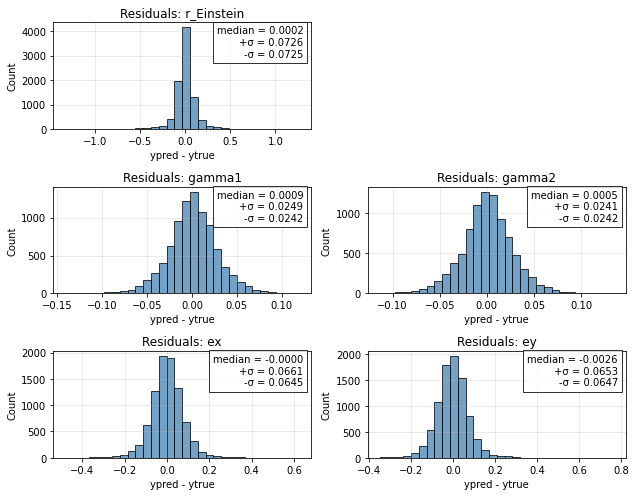

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(9, 7))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residus_sqrt_images_first.png", dpi=300, bbox_inches="tight")
plt.show()

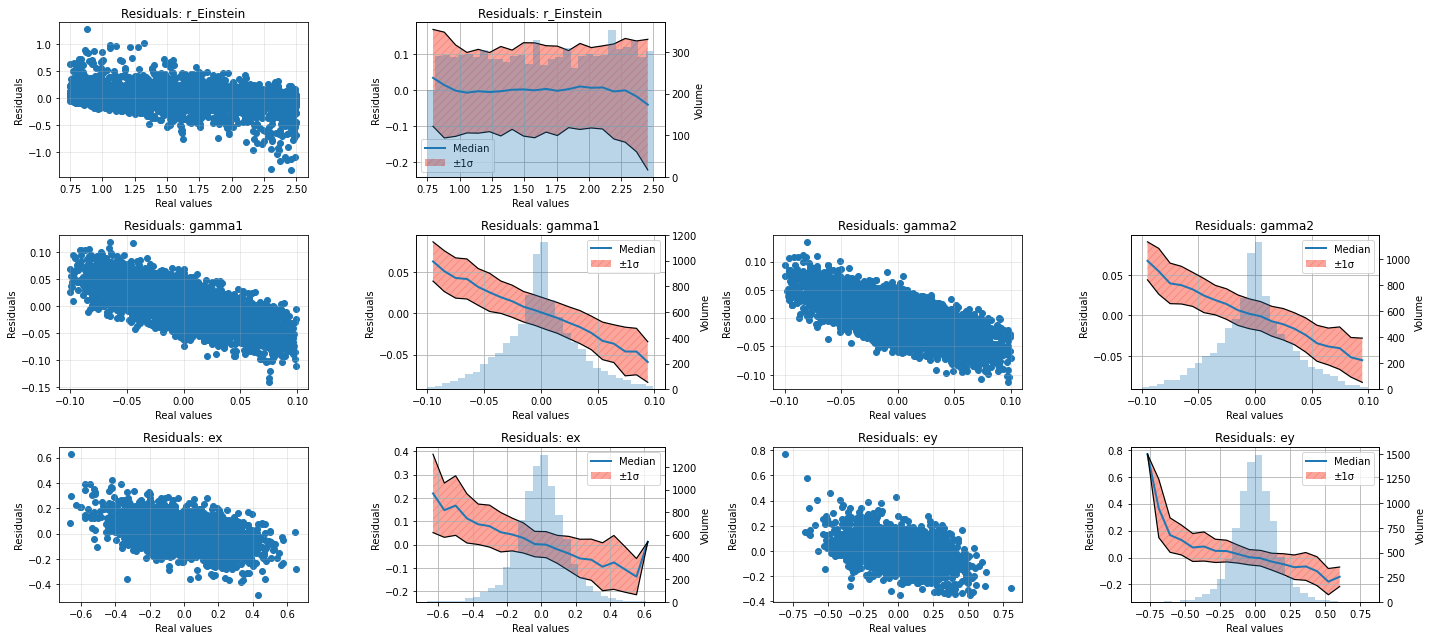

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min
error_denorm = y_pred_denorm - y_true_denorm

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(20, 9))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):
    plt.subplot(3, 4, places[i][0])
    plt.scatter(y_true_denorm[:,i], error_denorm[:,i])
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("Real values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    
    # Extract the variables
    x = y_true_denorm[:, i]
    y = error_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Residuals")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Residuals: {param_names[i]}")

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residuals_vs_true_sqrt_13.png", dpi=300, bbox_inches="tight")
plt.show()


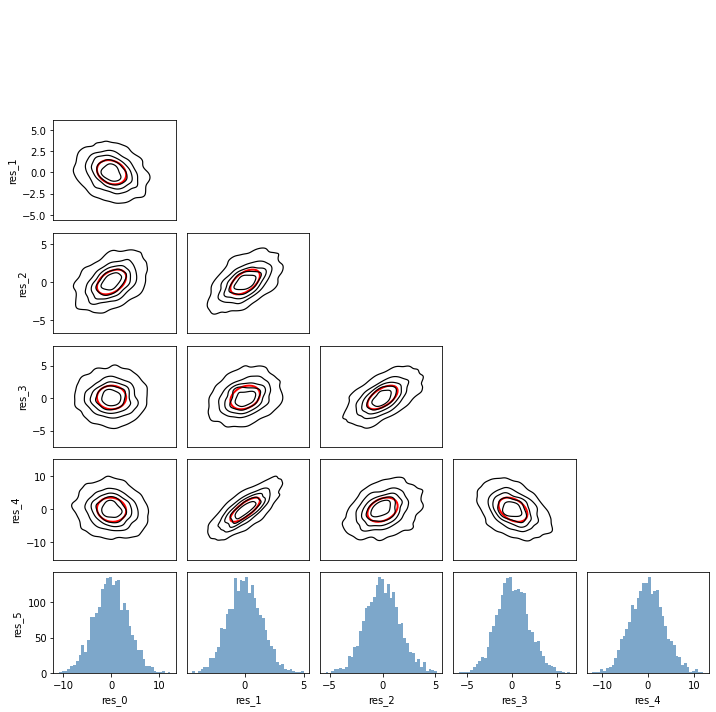

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse

# ----------------------------------------------------
# Generate random correlated residuals (example data)
# ----------------------------------------------------
np.random.seed(0)
N = 2000
n_params = 5

A = np.random.randn(n_params, n_params)
cov = A @ A.T
residuals = np.random.multivariate_normal(
    mean=np.zeros(n_params),
    cov=cov,
    size=N
)

# ----------------------------------------------------
# Function to draw 1-sigma ellipse
# ----------------------------------------------------
def plot_1sigma_ellipse(ax, x, y, n_std=1.0, **kwargs):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height,
        angle=theta,
        fill=False, lw=2, **kwargs
    )
    ax.add_patch(ellipse)

# ----------------------------------------------------
# Plot matrix (Fig‑5 style)
# ----------------------------------------------------
fig, axes = plt.subplots(n_params + 1, n_params, figsize=(10, 10))

for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]
        if i > j:
            # -------------------------
            # Lower triangle: contours
            # -------------------------
            sns.kdeplot(
                x=residuals[:, j],
                y=residuals[:, i],
                levels=6,
                color="black",
                linewidths=1.2,
                fill=False,
                ax=ax
            )

            # Add 1-sigma ellipse
            plot_1sigma_ellipse(ax, residuals[:, j], residuals[:, i], color="red")
#             ax.grid(True)

        else:
            # -------------------------
            # Upper triangle: empty
            # -------------------------
            ax.axis("off")

        # Clean axes
        if i == n_params - 1 and j <= i:
            ax.set_xticks([])
        else:
            ax.set_xticks([])

        if j == 0 and i != j:
            ax.set_ylabel(f"res_{i}")
        elif j != 0:
            ax.set_yticks([])
            
for h in range(n_params):
    ax = axes[-1, h]
    ax.hist(residuals[:, h], bins=40, color='steelblue', alpha=0.7)
    ax.set_xlabel(f"res_{h}")
    if h > 0:
        ax.set_yticks([])
    
#     ax.grid(True)
#     ax.set_ylabel(f"res_{i}")

axes[-1,0].set_ylabel(f"res_{n_params}")

# plt.suptitle("Residual Structure (Random Data) — Contours + 1σ Ellipse + Bottom Histograms", fontsize=18)
plt.tight_layout()
plt.show()


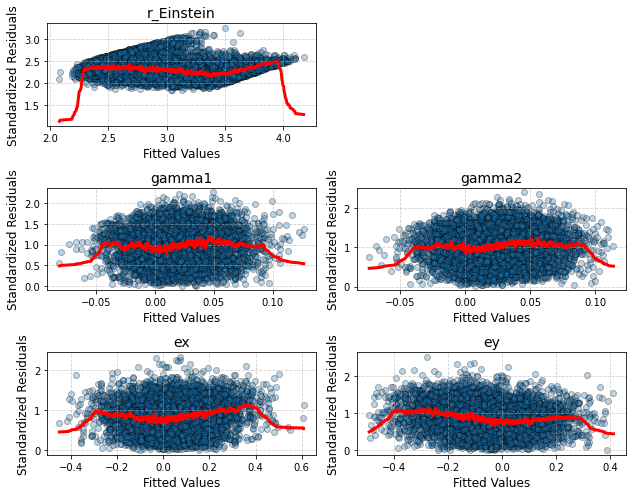

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(9, 7))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    fitted_vals = y_pred_denorm[:, i]
    std_resid = error_denorm[:, i] / np.std(error_denorm[:, i])
    sqrt_std_resid = np.sqrt(np.abs(std_resid))

    # Sort values for a clean line
    order = np.argsort(fitted_vals)
    x_sorted = fitted_vals[order]
    y_sorted = sqrt_std_resid[order]

    # Simple moving average smoothing
    window = 100  # adjust depending on dataset size
    kernel = np.ones(window) / window
    y_smooth = np.convolve(y_sorted, kernel, mode='same')
    
    plt.scatter(fitted_vals, sqrt_std_resid, alpha=0.3, edgecolor='k')

    # Add moving-average trend line
    plt.plot(x_sorted, y_smooth, color='red', linewidth=3)
    plt.title(f'{param_names[i]}', fontsize=14)
    plt.xlabel('Fitted Values', fontsize=12)
    plt.ylabel(r'Standardized Residuals', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residus_sqrt_images_first.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
np.sqrt(np.abs(std_resid)).shape

(8746,)

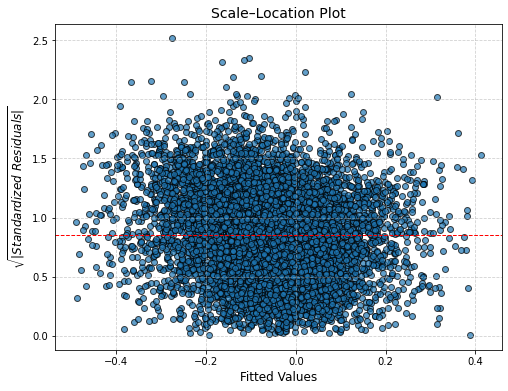

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(fitted_vals, np.sqrt(np.abs(std_resid)), alpha=0.7, edgecolor='k')
plt.axhline(y=np.mean(np.sqrt(np.abs(std_resid))), color='red', linestyle='--', linewidth=1)

plt.title('Scale–Location Plot', fontsize=14)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel(r'$\sqrt{|Standardized\ Residuals|}$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [48]:
import numpy as np

combined = np.concatenate([y_pred_denorm, y_true_denorm], axis=1)
print(combined.shape)  # Should output (8000, 10)


(8746, 10)


In [49]:
dg = pd.DataFrame(combined)
dg.columns = ["r_Einstein", "gamma1", "gamma2", "ex", "ey", "r_Einstein_t", "gamma1_t", "gamma2_t", "ex_t", "ey_t"]

In [50]:
names = ['e_einstein', 'e_gamma1', 'e_gamma2', 'e_ex', 'e_ey']
for i in range(5):
    dg[names[i]] = (dg.iloc[:,i] - dg.iloc[:,i+5])/dg.iloc[:,i+5] * 100


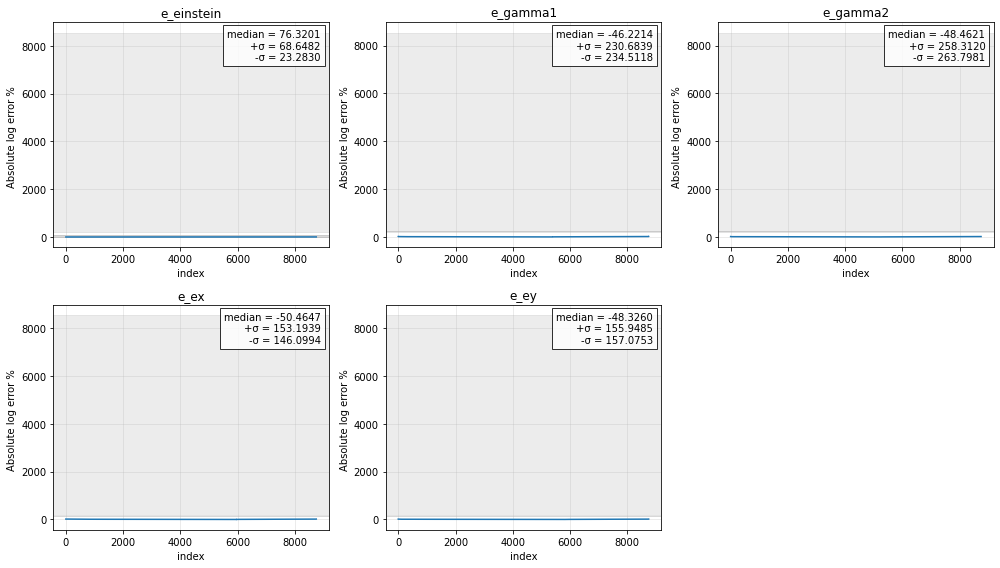

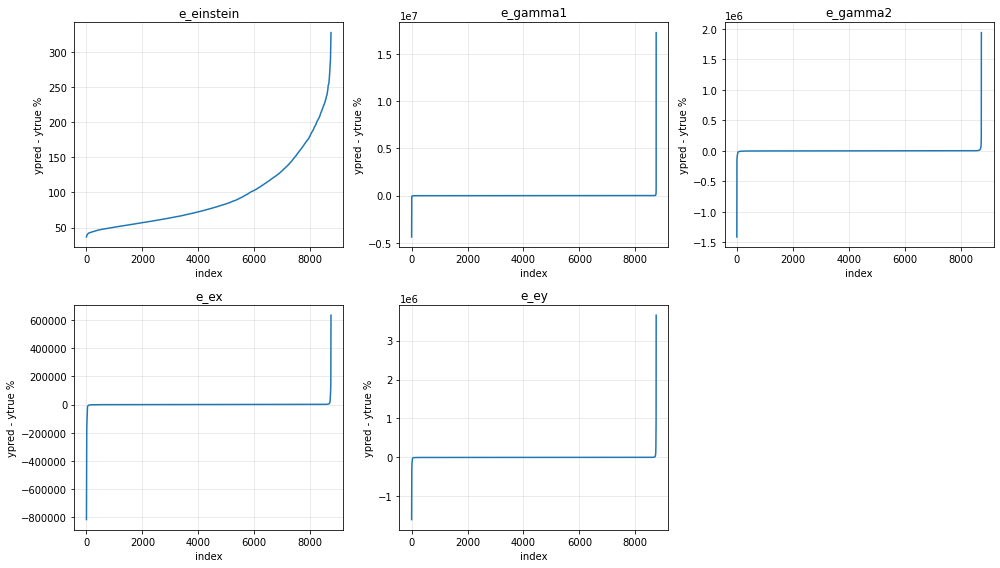

In [51]:
plt.figure(figsize = (14,8))

medians = np.median(dg[names], axis=0)
p16 = np.percentile(dg[names], 16, axis=0)
p84 = np.percentile(dg[names], 84, axis=0)

p22 = np.percentile(dg[names], 2.2, axis=0)
p97 = np.percentile(dg[names], 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians


for i in range(5):
    plt.subplot(2,3, i+1)
    plt.plot(np.log(abs(dg[names[i]].sort_values().reset_index()[names[i]])))
    sigma1 = 0.16 * len(dg)
    sigma2 = 0.02275 * len(dg)
    plt.axhspan(sigma_minus[i], sigma_plus[i], color='gray', alpha=0.3)
    plt.axhspan(sigma2, len(dg) - sigma2, color='gray', alpha=0.15)
#     plt.axvline(x=sigma1, color='red', linestyle='--', linewidth=2, label= '16 percentile')
#     plt.axvline(x=sigma2, color='red', linestyle='--', linewidth=2, label= '84 percentile')
    plt.grid()
    plt.title(names[i])
    plt.ylabel("Absolute log error % ")
    plt.xlabel("index")
    plt.grid(alpha=0.3)
    
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )
plt.tight_layout()
plt.show()

plt.figure(figsize = (14,8))
for i in range(5):
    plt.subplot(2,3, i+1)
    plt.plot(dg[names[i]].sort_values().reset_index()[names[i]])
    plt.grid()
    plt.title(names[i])
    plt.ylabel("ypred - ytrue %")
    plt.xlabel("index")
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [52]:
np.log(120)

4.787491742782046

In [53]:
# from IPython.display import Image

# Image("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnetmini.png")